# Tutorial 7: 3D Dust Mapping

This tutorial demonstrates line-of-sight dust modeling with brutus, fitting multi-cloud
models to stellar distance-extinction posteriors using nested sampling.

## Topics Covered

1. **Loading stellar posteriors** for distance and extinction
2. **Line-of-sight dust modeling** with multi-cloud models
3. **LOS dust fitting** with nested sampling (dynesty)

## Prerequisites

This tutorial optionally uses:
- Stellar posterior samples from Tutorial 5

The tutorial will generate synthetic data if these files are not available.

> **Requirement**: the line-of-sight fitting sections use the `dynesty` nested sampler, which is not a brutus dependency — install it with `pip install dynesty` before running this tutorial.


In [1]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import h5py

# Import tutorial utilities
from tutorial_utils import (
    set_plot_style,
    find_brutus_data_file,
    save_figure as save_fig_util,
)

# Set plot style
set_plot_style()
plt.rcParams['figure.figsize'] = (10, 6)

# Create plots directory if needed
plots_dir = Path('plots/tutorial_07')
plots_dir.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name):
    """Helper to save figures."""
    filepath = plots_dir / f"{name}.png"
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"  Saved: {filepath}")

## Line-of-Sight Dust Modeling

Real dust distributions often have discrete cloud structures along the line of sight.
The `brutus.analysis.los_dust` module provides tools to fit multi-cloud models to
stellar extinction measurements, decomposing the cumulative extinction into a
foreground component plus discrete cloud jumps at specific distances.

### Input Data

The LOS fitter works with **posterior samples** from BruteForce fits. Each star
contributes distance and extinction samples that collectively trace the
distance-reddening relation along the sightline.

Let's load stellar posteriors and examine the distance-extinction structure.

> **Note**: The LOS dust fitting in this tutorial uses the
> [dynesty](https://dynesty.readthedocs.io/) nested sampling package.
> Install it with `pip install dynesty` if you don't have it already.

In [2]:
# Try to load real stellar posterior samples or generate synthetic ones
print("Preparing stellar posterior samples for LOS dust modeling...\n")

try:
    # Try to find results from Tutorial 5 (Orion field, no-dust-prior fit)
    datafile = Path('Orion_l209.1_b-19.9_mist_nodust.h5')

    if not datafile.exists():
        datafile = find_brutus_data_file("Orion_l209.1_b-19.9_mist_nodust.h5")

    with h5py.File(datafile, 'r') as f:
        # Load distance and extinction samples
        dist_samples = f['samps_dist'][:] if 'samps_dist' in f else None
        av_samples = f['samps_red'][:] if 'samps_red' in f else None
        chi2 = f['obj_chi2min'][:] if 'obj_chi2min' in f else None
        nbands = f['obj_Nbands'][:] if 'obj_Nbands' in f else None

        if dist_samples is not None and av_samples is not None:
            print(f"Loaded {len(dist_samples)} stellar posterior samples from file")

            # Apply a loose chi2 cut to remove poor fits
            if chi2 is not None and nbands is not None:
                from scipy.stats import chi2 as chi2_dist
                # Goodness-of-fit p-value, not chi2/Nbands.
                dof = np.maximum(nbands - 3, 1)
                pvals = chi2_dist.sf(chi2, dof)
                good = pvals > 1e-6  # drop only the worst fits
                dist_samples = dist_samples[good]
                av_samples = av_samples[good]
                print(f"  After p-value > 1e-6 cut: {len(dist_samples)} stars kept")

            # Convert distances to distance modulus for LOS fitting
            dm_samples = 5 * np.log10(dist_samples * 1000) - 5  # kpc to distance modulus

            source = "Real Data"
        else:
            raise ValueError("No distance/extinction samples in file")

            

except (FileNotFoundError, ValueError, KeyError) as e:

    # Generate synthetic samples
    print("Generating synthetic stellar samples...")
    print(f"  (Real data not available: {e})\n")
    
    n_stars = 50
    n_samples = 100

    # Create synthetic distance modulus samples
    # Simulate stars at various distances with measurement uncertainties
    true_dm = np.random.uniform(7, 10, n_stars)  # True distance moduli
    dm_error = np.random.uniform(0.1, 0.3, n_stars)  # Uncertainties

    dm_samples = np.zeros((n_stars, n_samples))
    for i in range(n_stars):
        dm_samples[i] = np.random.normal(true_dm[i], dm_error[i], n_samples)

    # Create synthetic extinction samples (correlated with distance)
    # Simulate a dust cloud at distance modulus ~8.5
    cloud_dm = 8.5
    cloud_width = 0.3

    av_samples = np.zeros((n_stars, n_samples))
    for i in range(n_stars):
        # Background extinction
        av_bg = 0.3

        # Add cloud extinction for stars behind it
        for j in range(n_samples):
            if dm_samples[i, j] > cloud_dm:
                av_cloud = 1.5 * (1 - np.exp(-(dm_samples[i, j] - cloud_dm) / cloud_width))
                av_samples[i, j] = av_bg + av_cloud + np.random.normal(0, 0.1)
            else:
                av_samples[i, j] = av_bg * (dm_samples[i, j] / cloud_dm) + np.random.normal(0, 0.1)

    av_samples = np.maximum(0, av_samples)  # No negative extinction
    source = "Synthetic"

print(f"Using {source} stellar samples:")
print(f"  Stars: {len(dm_samples)}")
print(f"  Samples per star: {dm_samples.shape[1]}")
print(f"  Distance modulus range: [{dm_samples.min():.1f}, {dm_samples.max():.1f}]")
print(f"  A_V range: [{av_samples.min():.2f}, {av_samples.max():.2f}] mag")

Preparing stellar posterior samples for LOS dust modeling...

Loaded 207 stellar posterior samples from file


  After p-value > 1e-6 cut: 138 stars kept
Using Real Data stellar samples:
  Stars: 138
  Samples per star: 500
  Distance modulus range: [7.1, 21.2]
  A_V range: [0.00, 5.95] mag


  Saved: plots/tutorial_07/stellar_samples.png


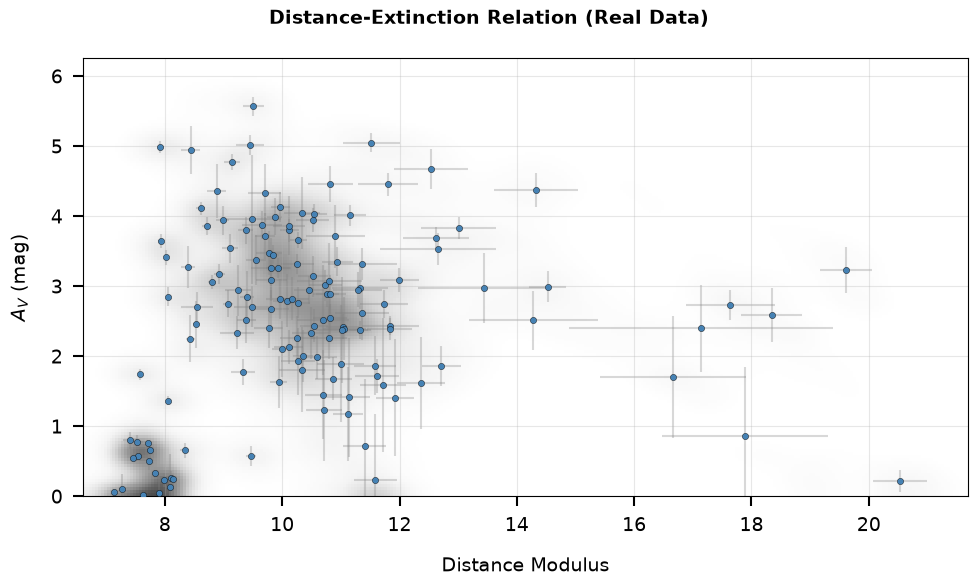

Stars: 138, DM range: [7.1, 20.5]
A_V range: [0.02, 5.57] mag


In [3]:
# Distance-extinction relation from stellar posteriors
from brutus.plotting import bin_pdfs_distred

# --- Bin posteriors into 2D distance-reddening PDFs ---
# bin_pdfs_distred expects (n_objects, n_samples) arrays for distance (in kpc)
# and reddening. We pass (dists, reds, dreds) as a 3-tuple.
dist_kpc = 10**((dm_samples + 5) / 5) / 1000  # DM -> kpc
rv_dummy = 3.32 * np.ones_like(av_samples)  # placeholder R(V)

# Determine plot span from data
dm_lo, dm_hi = float(np.nanmin(dm_samples)) - 0.5, float(np.nanmax(dm_samples)) + 0.5
av_lo, av_hi = 0.0, max(2.0, float(np.nanmax(av_samples)) + 0.3)
dist_lo = 10**((dm_lo + 5) / 5) / 1000
dist_hi = 10**((dm_hi + 5) / 5) / 1000

binned, xedges, yedges = bin_pdfs_distred(
    (dist_kpc, av_samples, rv_dummy),
    dist_type='distance_modulus',
    avlim=(av_lo, av_hi),
    span=((av_lo, av_hi), (dist_lo, dist_hi)),
    bins=(300, 150),
    smooth=0.02,
)
# binned shape: (n_stars, n_xbins, n_ybins) where x=DM, y=A_V

# Compute bin centers
xc = 0.5 * (xedges[:-1] + xedges[1:])  # distance modulus
yc = 0.5 * (yedges[:-1] + yedges[1:])  # A_V

# --- Build stacked 2D density (sum over all stars) ---
stacked = binned.sum(axis=0)

# --- Plot: single panel only (no marginals) ---
fig, ax_main = plt.subplots(figsize=(10, 6))

# Main panel: stacked 2D density + scatter
ax_main.pcolormesh(xedges, yedges, stacked.T, cmap='Greys', alpha=0.7)

# Overlay per-star medians
dm_median = np.median(dm_samples, axis=1)
dm_std = np.std(dm_samples, axis=1)
av_median = np.median(av_samples, axis=1)
av_std = np.std(av_samples, axis=1)
ax_main.errorbar(dm_median, av_median, xerr=dm_std, yerr=av_std,
                 fmt='none', ecolor='gray', alpha=0.3, zorder=1)
ax_main.scatter(dm_median, av_median, c='steelblue', s=20, zorder=5,
                edgecolor='k', linewidth=0.3)
ax_main.set_xlabel('Distance Modulus')
ax_main.set_ylabel('$A_V$ (mag)')
ax_main.set_ylim(bottom=0)
ax_main.grid(True, alpha=0.3)

fig.suptitle(f'Distance-Extinction Relation ({source})', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'stellar_samples')
plt.show()

print(f"Stars: {len(dm_median)}, DM range: [{dm_median.min():.1f}, {dm_median.max():.1f}]")
print(f"A_V range: [{av_median.min():.2f}, {av_median.max():.2f}] mag")

## Fitting a LOS Dust Model with Dynesty

The LOS fitter uses two key functions designed for nested sampling:

- **`los_clouds_priortransform(u, rlims, dlims)`**: Transforms unit cube draws into physical parameters. For an $n$-cloud model the parameter vector has $2n + 4$ elements: $[p_b, s_{\text{fore}}, s_{\text{back}}, A_{V,\text{fore}}, d_1, A_{V,1}, \ldots, d_n, A_{V,n}]$
- **`los_clouds_loglike_samples(theta, dsamps, rsamps, ...)`**: Log-likelihood of the cloud model given stellar distance/reddening posterior samples.

For a **1-cloud model** (`ndim=6`), the parameters are:

| Parameter | Meaning |
|-----------|---------|
| $p_b$ | Outlier fraction |
| $s_{\text{fore}}$ | Foreground smoothing scale |
| $s_{\text{back}}$ | Background smoothing scale |
| $A_{V,\text{fore}}$ | Foreground extinction (before cloud) |
| $d_1$ | Cloud distance (distance modulus) |
| $A_{V,1}$ | Total extinction (after cloud) |

Let's run a real nested sampling fit on the stellar posteriors.

In [4]:
# Run LOS dust fit with dynesty
from brutus.analysis import los_clouds_priortransform, los_clouds_loglike_samples
import dynesty
from dynesty.utils import resample_equal

# Set up 1-cloud model (ndim = 6)
ndim = 6

# Determine appropriate bounds from the data
dm_range = (float(dm_samples.min()) - 0.5, float(dm_samples.max()) + 0.5)
av_range = (0.0, max(3.0, float(av_samples.max()) + 0.5))

print(f"LOS fit setup:")
print(f"  Model: 1-cloud ({ndim} parameters)")
print(f"  Stars: {dm_samples.shape[0]}")
print(f"  Samples per star: {dm_samples.shape[1]}")
print(f"  Distance modulus bounds: [{dm_range[0]:.1f}, {dm_range[1]:.1f}]")
print(f"  A_V bounds: [{av_range[0]:.1f}, {av_range[1]:.1f}]")

def prior_transform(u):
    return los_clouds_priortransform(u, rlims=av_range, dlims=dm_range)

def loglike(theta):
    return los_clouds_loglike_samples(
        theta, dm_samples, av_samples,
        kernel='gauss', rlims=av_range, Ndraws=25, monotonic=True
    )

# Run nested sampling (rslice sampler is more efficient for this problem)
import time
print("\nRunning nested sampling...")
t0 = time.time()
sampler = dynesty.NestedSampler(loglike, prior_transform, ndim,
                                nlive=200, sample='rslice')
sampler.run_nested(print_progress=True, maxcall=250000)
results = sampler.results
t_run = time.time() - t0

print(f"  Completed in {t_run:.1f}s")
print(f"  Log-evidence: {results.logz[-1]:.1f} +/- {results.logzerr[-1]:.1f}")
print(f"  Iterations: {results.niter}")

# Extract weighted posterior
weights = np.exp(results.logwt - results.logz[-1])
weights /= weights.sum()
posterior = resample_equal(results.samples, weights)

param_names = ['P_b', 's_fore', 's_back', 'A_V_fore', 'd_cloud (DM)', 'A_V_total']
print(f"\nPosterior summary (median [16th, 84th]):")
for i, name in enumerate(param_names):
    med = np.median(posterior[:, i])
    lo, hi = np.percentile(posterior[:, i], [16, 84])
    print(f"  {name:20s}: {med:.3f}  [{lo:.3f}, {hi:.3f}]")

# Convert cloud distance to kpc
dm_cloud = np.median(posterior[:, 4])
dist_kpc = 10**((dm_cloud + 5) / 5) / 1000
delta_av = np.median(posterior[:, 5] - posterior[:, 3])
print(f"\nCloud properties:")
print(f"  Distance: {dist_kpc:.2f} kpc (DM = {dm_cloud:.1f})")
print(f"  Foreground A_V: {np.median(posterior[:, 3]):.3f} mag")
print(f"  Extinction jump at cloud: {delta_av:.3f} mag")

LOS fit setup:
  Model: 1-cloud (6 parameters)
  Stars: 138
  Samples per star: 500
  Distance modulus bounds: [6.6, 21.7]
  A_V bounds: [0.0, 6.5]

Running nested sampling...


0it [00:00, ?it/s]

56it [00:00, 559.73it/s, bound: 0 | nc: 2 | ncall: 322 | eff(%): 17.391 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.209]

112it [00:00, 556.13it/s, bound: 0 | nc: 2 | ncall: 423 | eff(%): 26.478 | loglstar:   -inf < -598.787 <    inf | logz: -605.482 +/-    nan | dlogz: 355.807 >  0.209]

168it [00:00, 453.85it/s, bound: 0 | nc: 1 | ncall: 580 | eff(%): 28.966 | loglstar:   -inf < -511.578 <    inf | logz: -517.823 +/-    nan | dlogz: 284.026 >  0.209]

...

3862it [02:48, 18.20it/s, bound: 94 | nc: 63 | ncall: 174132 | eff(%):  2.218 | loglstar:   -inf < -190.994 <    inf | logz: -207.870 +/-    nan | dlogz:  0.214 >  0.209]

3865it [02:48, 18.47it/s, bound: 94 | nc: 55 | ncall: 174274 | eff(%):  2.218 | loglstar:   -inf < -190.986 <    inf | logz: -207.868 +/-    nan | dlogz:  0.211 >  0.209]

3867it [02:48, 17.96it/s, bound: 94 | nc: 50 | ncall: 174375 | eff(%):  2.218 | loglstar:   -inf < -190.981 <    inf | logz: -207.868 +/-    nan | dlogz:  0.209 >  0.209]

3867it [02:48, 22.89it/s, +200 | bound: 94 | nc: 1 | ncall: 174575 | eff(%):  2.332 | loglstar:   -inf < -189.899 <    inf | logz: -207.766 +/-    nan | dlogz:  0.001 >  0.209]

  Completed in 169.1s
  Log-evidence: -207.8 +/- 0.4
  Iterations: 3867

Posterior summary (median [16th, 84th]):
  P_b                 : 0.151  [0.106, 0.205]
  s_fore              : 0.064  [0.050, 0.080]
  s_back              : 0.107  [0.097, 0.118]
  A_V_fore            : 0.240  [0.083, 0.390]
  d_cloud (DM)        : 8.348  [8.288, 8.410]
  A_V_total           : 2.927  [2.833, 3.015]

Cloud properties:
  Distance: 0.47 kpc (DM = 8.3)
  Foreground A_V: 0.240 mag
  Extinction jump at cloud: 2.688 mag


  Saved: plots/tutorial_07/los_dust_fit.png


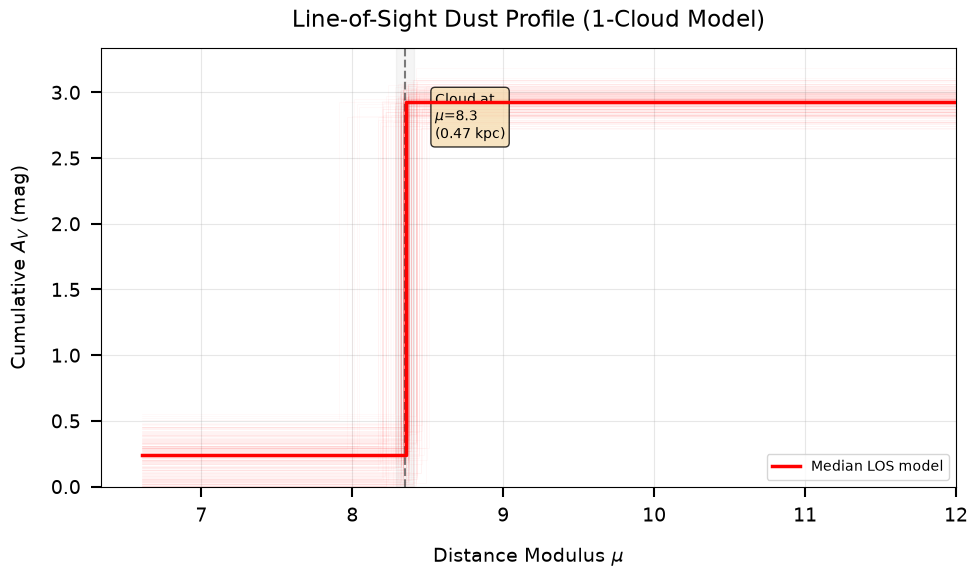

LOS dust fit visualization complete


In [5]:
# Visualize the LOS dust fit results
fig, ax = plt.subplots(figsize=(10, 6))

# --- Foreground: LOS model step functions from dynesty posterior ---
# Each posterior sample defines: A(V) = Av_fore for d < d1,
#                                A(V) = Av_total for d >= d1
# Parameters: [p_b, s_fore, s_back, Av_fore, d1, Av_total]
dm_grid = np.linspace(xedges[0], 12, 500)

n_plot = min(200, len(posterior))
plot_idx = np.random.choice(len(posterior), n_plot, replace=False)

for k in plot_idx:
    av_fore_k = posterior[k, 3]
    d_cloud_k = posterior[k, 4]
    av_total_k = posterior[k, 5]
    step = np.where(dm_grid < d_cloud_k, av_fore_k, av_total_k)
    ax.step(dm_grid, step, where='post', color='red', alpha=0.03, lw=0.5)

# Median model step function
av_fore_med = np.median(posterior[:, 3])
d_cloud_med = np.median(posterior[:, 4])
av_total_med = np.median(posterior[:, 5])
step_med = np.where(dm_grid < d_cloud_med, av_fore_med, av_total_med)
ax.step(dm_grid, step_med, where='post', color='red', lw=2.5,
        label='Median LOS model', zorder=5)

# Mark cloud location
dm_cloud_lo, dm_cloud_hi = np.percentile(posterior[:, 4], [16, 84])
ax.axvline(d_cloud_med, color='k', ls='--', alpha=0.5, lw=1.5)
ax.axvspan(dm_cloud_lo, dm_cloud_hi, alpha=0.08, color='gray')

dist_kpc_med = 10**((d_cloud_med + 5) / 5) / 1000
ax.text(d_cloud_med + 0.2, ax.get_ylim()[1] * 0.9,
        f'Cloud at\n$\mu$={d_cloud_med:.1f}\n({dist_kpc_med:.2f} kpc)',
        fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Distance Modulus $\mu$')
ax.set_ylabel('Cumulative $A_V$ (mag)')
ax.set_title('Line-of-Sight Dust Profile (1-Cloud Model)')
ax.set_xlim(right=12)
ax.set_ylim(bottom=0)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'los_dust_fit')
plt.show()

print('LOS dust fit visualization complete')

## Summary and Key Takeaways

This tutorial has demonstrated line-of-sight dust modeling with brutus:

### Key Concepts

1. **LOS Dust Modeling** (`brutus.analysis.los_dust`)
   - Multi-cloud models fit discrete dust structures along the line of sight
   - Prior transform + log-likelihood designed for nested sampling (dynesty)
   - Compare evidence (logZ) across models with different numbers of clouds.
     With the default `monotonic=True`, non-monotone profiles are rejected in
     the likelihood, shrinking the sampled prior volume, so add back the
     mode-dependent offset — ln((n+1)!) for an $n$-cloud fit in the default
     mode — to each logZ before comparing (see the
     `los_clouds_loglike_samples` documentation)

2. **Stellar Posteriors**
   - Per-star distance and extinction samples trace the distance-reddening relation
   - `bin_pdfs_distred` bins and smooths posteriors for visualization

### Next Steps

- **Tutorial 8**: Photometric Calibration
- Try fitting 2-cloud and 3-cloud models and comparing evidence (with the
  ln((n+1)!) offsets noted above)
- Apply LOS fitting across multiple sightlines for a 3D dust map

In [6]:
print("Tutorial 7 Complete!")
print("=" * 60)
print("\nGenerated plots:")
for plot_file in sorted(plots_dir.glob('*.png')):
    print(f"  - {plot_file.name}")

Tutorial 7 Complete!

Generated plots:
  - dust_sightlines.png
  - kernel_comparison.png
  - los_dust_fit.png
  - stellar_samples.png
